# Performing curation of all imodulons at once now.

- Based on GRN, OrthoICA, and functional annotation, I will rename all imodulons all at once
- If manual changes to the imodulon names after new insights from subsequent analysis, go directly to the end

In [1]:
from pymodulon.io import *
from pymodulon.plotting import *
from pymodulon.compare import compare_ica

from pymodulon.enrichment import compute_enrichment, compute_annotation_enrichment

import os
from os import path

import pandas as pd

from matplotlib import cm, colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### path to different data

In [2]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

### different required data need to be loaded

In [7]:
ica_data = load_json_model(path.join(interim_dir,'ctherm_raw.json.gz'))

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/p

In [6]:
# also load previous one
ica_data_prev = load_json_model(path.join(data_dir,'ctherm_prev.json.gz'))
df_rename_imod = pd.read_csv('../5_characterize_iModulons/results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t', index_col=0)

dict_rename_imod = df_rename_imod[['IM']].to_dict()['IM']

# rename all at once
ica_data_prev.rename_imodulons(dict_rename_imod)

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/p

In [69]:
# Get genes for each iModulon

df_prev_new_imod_map = pd.DataFrame(columns=['IM_prev', 'f1_score', 'pval'])

dict_imodulon_genes = {im: ica_data.view_imodulon(im).index.tolist()
                  for im in ica_data.imodulon_names}

dict_imodulon_genes_prev = {im: ica_data_prev.view_imodulon(im).index.tolist()
                  for im in ica_data_prev.imodulon_names}


for imod_prev, genes_prev in dict_imodulon_genes_prev.items():
    for imod, genes in dict_imodulon_genes.items():
        res = compute_enrichment(genes_prev, 
                                genes,
                                ica_data.gene_names)
        if res.pvalue < 0.05 and res.f1score>0.7:
            df_prev_new_imod_map.loc[imod] = imod_prev, res.f1score, res.pvalue

In [70]:
df_prev_new_imod_map

,IM_prev,f1_score,pval
27,Translation,0.965517,8.688726e-91
15,UC-1,0.857143,2.408582e-30
49,Urea,0.967742,1.832289e-69
3,UC-2,0.838710,5.084692e-32
50,UC-3,0.909091,3.456322e-15
...,...,...,...
66,Rex_2471,0.800000,3.908130e-21
59,Co/Ni-tp-2,0.909091,3.456322e-15
58,UC-12,0.777778,3.674517e-67
62,UC-13,0.818182,1.750110e-23


In [8]:
# GRN
df_grn_ica = pd.read_csv(path.join(interim_dir, 'grn_from_ica.tsv'), sep='\t', index_col=0)
df_grn_ica.set_index('index', inplace=True)

dict_grn_ica = df_grn_ica[['regulator']].to_dict()['regulator']

In [9]:
# orthologous ICA analysis
out_dir_bbh = path.join(external_dir, 'orthoICA', 'orthologous_imodulons', 'imodulon_prot_bbh') #ctherm_nf/external/orthoICA/orthologous_imodulons
M_dir = path.join(external_dir, 'orthoICA', 'orthologous_imodulons', 'ica_data', 'M') #ctherm_nf/external/orthoICA/orthologous_imodulons/ica_data/M
query_org = 'Clostridium_thermocellum'
M2 = pd.read_csv(path.join(data_dir, 'M.csv'), index_col=0) #for ctherm

df_ortho_ica = pd.DataFrame(columns=['imod_ref', 'imod_ctherm', 'distance_pearson', 'from'])

for file in os.listdir(M_dir):
    if file.startswith('.DS_'):
        continue
    
    org_name = file.split('_modulome_')[0]
    M1 = pd.read_csv(path.join(M_dir, file), index_col=0)
    

    matches, dot = compare_ica(M1=M1, M2=M2,
                                ortho_file=f'{out_dir_bbh}/{org_name}_curated_vs_{query_org}_curated_parsed.csv',
                                method='pearson',
                                show_all=True
                                )
    for items in matches:
        df_ortho_ica.loc[len(df_ortho_ica)] = items[0], items[1], np.round(items[2], 2), org_name

# save this dataframe
# df_ortho_ica.to_csv(path.join(external_dir, 'orthoICA', 'all_matches_imodulons_cthermocellum.tsv'), sep='\t')

In [12]:
df_ortho_ica.loc[df_ortho_ica.imod_ctherm=='8']

,imod_ref,imod_ctherm,distance_pearson,from
7,SigD,8,0.52,Bacillus_subtilis
21,FlhDC-2,8,0.32,Escherichia_coli
37,FliA,8,0.54,Escherichia_coli
61,FleN-2,8,0.29,Pseudomonas_aeruginosa
69,Uncharacterized-9,8,0.27,Pseudomonas_aeruginosa
70,FleN-1,8,0.28,Pseudomonas_aeruginosa


### LOAD IT AGAIN

In [6]:
### orthologous ICAs
df_ortho_ica = pd.read_csv(path.join(external_dir, 'orthoICA', 'all_matches_imodulons_cthermocellum.tsv'), sep='\t', index_col=0)

# cutoff and then cluster them
df_ortho_ica_thres = df_ortho_ica.loc[df_ortho_ica['distance_pearson']>0.5]
# make sure I don't have any from GRN
df_ortho_ica_thres = df_ortho_ica_thres.loc[~df_ortho_ica_thres['imod_ctherm'].isin([k for k in dict_grn_ica.keys()])]


# also ensure the source is also provided
df_ortho_ica_thres['from_abbv'] = [k.split('_')[0][0].lower()+k.split('_')[-1][0].lower() for k in df_ortho_ica_thres['from'].to_list()]
df_ortho_ica_thres['imod_ref'] = df_ortho_ica_thres['imod_ref'] + '__' + df_ortho_ica_thres['from_abbv']

df_ortho_ica_thres_grouped = df_ortho_ica_thres.groupby('imod_ctherm')['imod_ref'].apply(list)

dict_ortho_ica_thres_grouped = df_ortho_ica_thres_grouped.to_dict()
dict_ortho_ica_thres_grouped

{8: ['SigD__bs', 'FliA__ec'],
 23: ['Arginine__ec'],
 25: ['Cysteine-1__ec', 'CysB-2__pa', 'CysB-3__pa'],
 27: ['stringent response__bs',
  'Translation__ec',
  'Unc_8__sp',
  'Translational-1__pa',
  'Translation-1__sa'],
 30: ['CysB-2__pa'],
 31: ['Rex__bs', 'Rex-2__sa'],
 40: ['Histidine__ec'],
 43: ['PyrR__bs', 'Pyrimidine__ec', 'PyrR__sp', 'PyrR__sa'],
 44: ['Ribose__ec'],
 49: ['Lrp__ec', 'Hot TALE 16__ec', 'Vir-1__sa', 'MgrA__sa'],
 51: ['G-box__bs', 'Purine__ec', 'PurR__sp', 'PurR__sa'],
 52: ['SwrA__bs']}

In [12]:
df_ortho_ica.loc[df_ortho_ica['imod_ctherm']==49]

,imod_ref,imod_ctherm,distance_pearson,from
9,TnrA-2,49,0.36,Bacillus_subtilis
27,YjfJ,49,0.36,Escherichia_coli
28,Lrp,49,0.75,Escherichia_coli
43,Hot TALE 16,49,0.51,Escherichia_coli
50,PurR,49,0.26,Streptococcus_pyogenes
74,Vir-1,49,0.82,Staphylococcus_aureus
84,MgrA,49,0.53,Staphylococcus_aureus


In [13]:
# manually change the dictionary. If one organism, keep it. If multiple source, then don't
dict_ortho_ica_thres_grouped[8] = ['SigD/FliA', 'orthoICA', 'multiple'] #two sources
dict_ortho_ica_thres_grouped[23] = ['Arginine', 'orthoICA', 'ec'] #KEGG Module M00323 refers to the Urea transport system. Does not match Lrp from orthoICA
dict_ortho_ica_thres_grouped[25] = ['Cysteine-1', 'orthoICA', 'ec'] #makes sense
dict_ortho_ica_thres_grouped[27] = ['Translation', 'orthoICA', 'multiple'] #multiple
dict_ortho_ica_thres_grouped[30] = ['CysB-2', 'orthoICA', 'pa'] #Does not match Cysteine from orthoICA
dict_ortho_ica_thres_grouped[31] = ['Rex', 'orthoICA', 'multiple']
dict_ortho_ica_thres_grouped[40] = ['Histidine', 'orthoICA', 'ec']
dict_ortho_ica_thres_grouped[43] = ['PyrR', 'orthoICA', 'multiple']
dict_ortho_ica_thres_grouped[44] = ['Ribose', 'orthoICA', 'ec'] #M00212 is Ribose.
dict_ortho_ica_thres_grouped[49] = ['Vir-1', 'orthoICA', 'sa'] #highest this
dict_ortho_ica_thres_grouped[51] = ['PurR', 'orthoICA', 'multiple']
dict_ortho_ica_thres_grouped[52] = ['SwrA', 'orthoICA', 'bs']

In [14]:
# imod_of_interest = 46
# for x in ica_data.view_imodulon(imod_of_interest).sort_values('gene_weight', ascending=False).index.to_list():
#     print(x)

# ica_data.view_imodulon(imod_of_interest).sort_values('gene_weight', ascending=False)

In [15]:
# DF_enrichments[DF_enrichments.imodulon==imod_of_interest].sort_values('f1score',ascending=False)

In [16]:
### gene info
df_gene_info = pd.read_csv(path.join(data_dir, 'gene_info.csv'), index_col=0)
df_gene_info.head()

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs
locus_tag,,,,,,,,,,,,,,
Clo1313_0001,dnaA,CP002416.1,NaN,212,1543,+,chromosomal replication initiator protein DnaA,No COG annotation,UPI0001B1F046,Op0,ATP binding; DNA replication origin binding; l...,DNA replication initiation; regulation of DNA ...,AAA+_ATPase;Chromosome_initiator_DnaA;Chromoso...,NaN
Clo1313_0002,RS00015,CP002416.1,NaN,1793,2893,+,DNA polymerase III%2C beta subunit,No COG annotation,UPI00017E1F7F,Op1,NaN,NaN,DNA_clamp_sf;DNA_polIII_beta;DNA_polIII_beta_C...,NaN
Clo1313_0003,yaaA,CP002416.1,NaN,2909,3115,+,S4 domain protein YaaA,No COG annotation,UPI000038F4E6,Op1,NaN,NaN,RNA-bd_S4-rel_YaaA;S4_RNA-bd;S4_RNA-bd_sf;,NaN
Clo1313_0004,recF,CP002416.1,NaN,3133,4242,+,DNA replication and repair protein RecF,No COG annotation,UPI00003C8C54,Op1,ATP binding; single-stranded DNA binding,DNA replication; DNA synthesis involved in DNA...,DNA-binding_RecF;DNA-binding_RecF_CS;P-loop_NT...,NaN
Clo1313_0005,RS00030,CP002416.1,NaN,4410,4724,+,hypothetical protein,Function unknown,UPI000038F4E8,Op2,NaN,NaN,RemA-like;,DUF370


In [17]:
DF_enrichments = pd.read_csv(path.join(data_dir,'functional_enrichments.csv'),index_col=0)
DF_enrichments.head()

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
0,2,L-tryptophan biosynthesis,2.510499e-11,4.744843e-09,0.800000,0.666667,0.727273,4.0,6.0,5.0,biocyc,NaN,NaN
1,7,"(1,4)-&beta;-D-xylan degradation",9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
2,7,cellulose and hemicellulose degradation (cellu...,9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
3,10,fatty acid biosynthesis initiation (type II),6.927798e-07,1.309354e-04,0.230769,0.600000,0.333333,3.0,5.0,13.0,biocyc,NaN,NaN
4,10,even <i>iso</i>-branched-chain fatty acid bios...,3.849618e-06,3.637889e-04,0.230769,0.375000,0.285714,3.0,8.0,13.0,biocyc,NaN,NaN


#### Add iModulon category for regulatory ones before moving the iModulon of interest -- ethanol production function

DO not run this after finding all the imodulons. ica_data cannot be loaded with string indices

This is only done to find the uncharacterized imodulons

In [18]:
# # # rename the ones that are already from regulators
# ica_data.rename_imodulons(dict_grn_ica)

# # # also use orthoICA
# ica_data.rename_imodulons({k:v[0] for k ,v in dict_ortho_ica_thres_grouped.items()})


# GRN for regulation in C. thermocellum
for i,row in ica_data.imodulon_table.iterrows():
    if pd.notnull(row.regulator):
        ica_data.imodulon_table.loc[i, 'category'] = 'regulatory'
    elif pd.notnull(row.single_gene):
        ica_data.imodulon_table.loc[i, 'category'] = 'single_gene'
    else:
        if i in dict_ortho_ica_thres_grouped.keys() or i in dict_ortho_ica_thres_grouped.values():
            ica_data.imodulon_table.loc[i, 'category'] = 'orthoICA'
        else:
            ica_data.imodulon_table.loc[i, 'category'] = 'uncharacterized'

# Inspect all iModulons without an automated annotation

In [19]:
unchar_imods = ica_data.imodulon_table[ica_data.imodulon_table.category == 'uncharacterized']

In [20]:
# we begin with the ones with highest variance
unchar_imods.sort_values('explained_variance', ascending=False)

,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs,single_gene,explained_variance,category
45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,NaN,NaN,0.039654,uncharacterized
28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72,NaN,NaN,0.028296,uncharacterized
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,NaN,NaN,0.023456,uncharacterized
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,NaN,NaN,0.023023,uncharacterized
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47,NaN,NaN,0.021862,uncharacterized
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,0.021162,uncharacterized
39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,NaN,NaN,0.018591,uncharacterized
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,NaN,NaN,0.018511,uncharacterized
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,NaN,NaN,0.016772,uncharacterized
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108,NaN,NaN,0.016509,uncharacterized


In [21]:
for x in unchar_imods.index.to_list():
    try:
        annotation = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['annotation'].values[0]
        source = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['source'].values[0]
    except IndexError:
        annotation = ''
        source = ''

    print(x, annotation, source)

0 DDE_Tnp_1_3 pfam
1  
2 M00023 kegg_module
3  
5 map00970 kegg_pathway
6  
9  
10 fatty acid biosynthesis initiation (type II) biocyc
11 Transposase_mut pfam
12 M00212 kegg_module
13 pyruvate fermentation to acetate IV biocyc
14 HTH_21 pfam
15  
16 Glyco_hydro_9 interpro
18 LysM interpro
19 Transposase_mut pfam
20  
21 flavin biosynthesis I (bacteria and plants) biocyc
22 M00434 kegg_module
24  
26 ammonia assimilation cycle III biocyc
28 Thioredoxin-like_sf interpro
29  
32  
34  
35 M00121 kegg_module
36 M00245 kegg_module
37 dCache_1 pfam
38 M00299 kegg_module
39 FAD/NAD-binding_dom interpro
41 M00527 kegg_module
45 M00175 kegg_module
46 TetR_0692 GRN
47  
48 Beta-glucanase-like interpro
50  
53  
54 LexA_1449 GRN
55 peptidoglycan biosynthesis I (<I>meso</I>-diaminopimelate containing) biocyc
57  
58  
59 M00245 kegg_module
60 map00195 kegg_pathway
61  
62  
63 2Fe-2S_thioredx pfam
64  
65 M00506 kegg_module


#### individual imodulons, for the ones that I could not identify the right imodulon names, iteratively went through each and then changed thresholds if needed

In [58]:
imod_of_interest = 9
# for x in ica_data.view_imodulon(imod_of_interest).sort_values('gene_weight', ascending=False).index.to_list():
#     print(x)
ica_data.view_imodulon(imod_of_interest).sort_values(['gene_weight', 'operon'], ascending=False).head(20)

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_2815,0.305879,RS14300,CP002416.1,NaN,3307455,3308315,-,hypothetical protein,Function unknown,UPI0001B1EE63,Op1909,NaN,NaN,Cthe_2159;,Cthe_2159,NaN
Clo1313_0826,0.160957,Clo1313_0826,CP002416.1,NaN,953401,953499,+,hypothetical protein,No COG annotation,UPI0001F3298E,Op552,NaN,NaN,NaN,NaN,NaN
Clo1313_2812,0.137292,RS14285,CP002416.1,NaN,3304274,3306169,-,S-layer domain-containing protein,Cell wall/membrane/envelope biogenesis,UPI000038FCE5,Op1906,NaN,NaN,Bacterial_rp_domain;Cell_Envelope_Struct_Comp;...,Chlam_PMP;Flg_new;SLH,NaN
Clo1313_2813,0.127697,RS14290,CP002416.1,NaN,3306229,3306507,-,hypothetical protein,Inorganic ion transport and metabolism,UPI000038FCE6,Op1907,NaN,NaN,NaN,SLH,NaN
Clo1313_1155,-0.118371,RS05865,CP002416.1,NaN,1373997,1375235,+,Glycine hydroxymethyltransferase,Amino acid transport and metabolism,UPI000038F8EA,Op793,NaN,NaN,PyrdxlP-dep_Trfase;PyrdxlP-dep_Trfase_major;Py...,SHMT,NaN


In [45]:
DF_enrichments[DF_enrichments.imodulon==imod_of_interest].sort_values('f1score',ascending=False)

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
8,5,map00970,0.000042,0.00806,0.125,0.166667,0.142857,5.0,30.0,40.0,kegg_pathway,Aminoacyl-tRNA biosynthesis,NaN


<Axes: ylabel='5 iModulon\nActivity'>

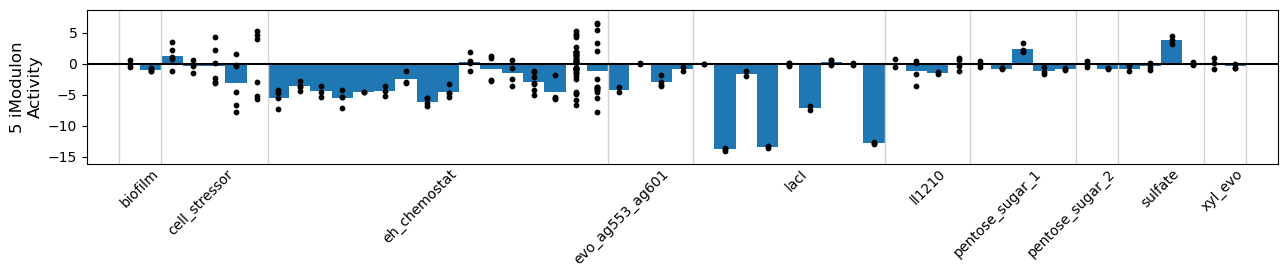

In [44]:
plot_activities(ica_data, imod_of_interest)

## Adjust some thresholds -- if no genes present (62, 53)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Text(13.222222222222216, 0.5, 'Gene Weights')

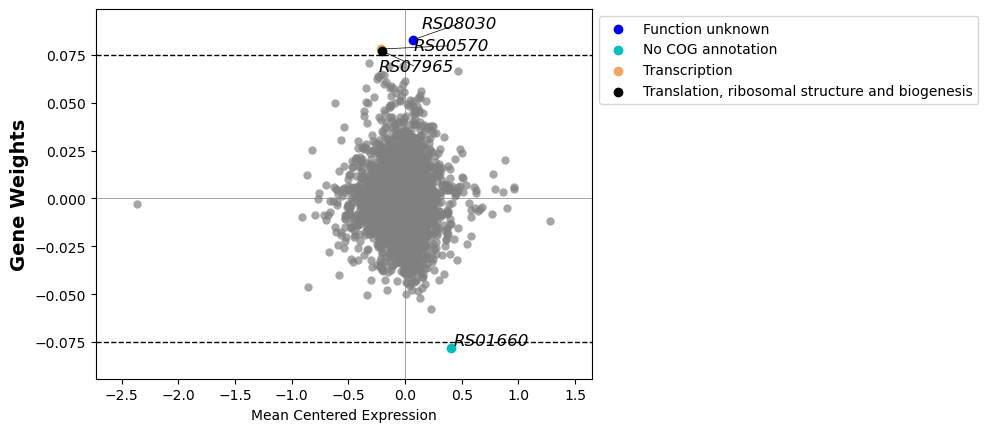

In [334]:
imod_of_interest = 50
ax = plot_gene_weights(ica_data, imod_of_interest, by='log-tpm-norm')

labels_of_interest = list() #any labels that I would like to keep

# for t in ax.texts:
#     if t.get_text() not in labels_of_interest:
#         t.remove()


ax.set_ylabel('Gene Weights', fontdict={'weight':'bold', 'size':14})

In [248]:
dict_change_threshold = {50: 0.075,
                        #  53: 0.075
                        }

for imod, new_thres in dict_change_threshold.items():
    ica_data.change_threshold(imod, new_thres)

# Recalculate enrichments
ica_data.compute_trn_enrichment([k for k in dict_change_threshold.keys()], save=True)

,imodulon,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs


In [335]:
ica_data.view_imodulon(50)

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_0107,0.078106,RS00570,CP002416.1,NaN,122010,122453,+,transcriptional regulator%2C BadM/Rrf2 family,Transcription,UPI00003C8E1E,Op79,,,Tscrpt_reg_Rrf2;WH-like_DNA-bd_sf;WH_DNA-bd_sf;,Rrf2,
Clo1313_0322,-0.078103,RS01660,CP002416.1,NaN,353207,353581,+,hypothetical protein,No COG annotation,UPI000038FB52,Op214,,,,-,
Clo1313_1578,0.077329,RS07965,CP002416.1,NaN,1835747,1837387,+,glutamyl-tRNA synthetase,"Translation, ribosomal structure and biogenesis",UPI00003C8F4E,Op1095,,,aa-tRNA-synth_I_cd-bd;aa-tRNA-synth_I_codon-bd...,tRNA-synt_1c,AraC_0222
Clo1313_1591,0.082888,RS08030,CP002416.1,NaN,1855017,1855265,+,hypothetical protein,Function unknown,UPI00003C8CA0,Op1105,,,Ubiquitin-like_dom;Ubiquitin-like_domsf;YukD-l...,YukD,


### check for expression vs activity correlation

In [27]:
from scipy.stats import pearsonr, spearmanr

In [41]:
df_gene_info

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs
locus_tag,,,,,,,,,,,,,,
Clo1313_0001,dnaA,CP002416.1,NaN,212,1543,+,chromosomal replication initiator protein DnaA,No COG annotation,UPI0001B1F046,Op0,ATP binding; DNA replication origin binding; l...,DNA replication initiation; regulation of DNA ...,AAA+_ATPase;Chromosome_initiator_DnaA;Chromoso...,NaN
Clo1313_0002,RS00015,CP002416.1,NaN,1793,2893,+,DNA polymerase III%2C beta subunit,No COG annotation,UPI00017E1F7F,Op1,NaN,NaN,DNA_clamp_sf;DNA_polIII_beta;DNA_polIII_beta_C...,NaN
Clo1313_0003,yaaA,CP002416.1,NaN,2909,3115,+,S4 domain protein YaaA,No COG annotation,UPI000038F4E6,Op1,NaN,NaN,RNA-bd_S4-rel_YaaA;S4_RNA-bd;S4_RNA-bd_sf;,NaN
Clo1313_0004,recF,CP002416.1,NaN,3133,4242,+,DNA replication and repair protein RecF,No COG annotation,UPI00003C8C54,Op1,ATP binding; single-stranded DNA binding,DNA replication; DNA synthesis involved in DNA...,DNA-binding_RecF;DNA-binding_RecF_CS;P-loop_NT...,NaN
Clo1313_0005,RS00030,CP002416.1,NaN,4410,4724,+,hypothetical protein,Function unknown,UPI000038F4E8,Op2,NaN,NaN,RemA-like;,DUF370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Clo1313_3029,RS15410,CP002416.1,NaN,3558840,3559460,-,single-stranded nucleic acid binding R3H domai...,Function unknown,UPI0001B1F047,Op2051,NaN,NaN,Jag_KH;Jag_N_dom_sf;KH_dom;KH_dom-like_a/b;KH_...,Jag_N;KH_4;R3H
Clo1313_3030,RS15415,CP002416.1,NaN,3559461,3560336,-,membrane protein insertase%2C YidC/Oxa1 family,"Intracellular trafficking, secretion, and vesi...",UPI000038F805,Op2051,NaN,NaN,YidC/ALB3/OXA1/COX18;YidC/Oxa/ALB_C;YidC_ALB_C;,60KD_IMP
Clo1313_3031,yidD,CP002416.1,NaN,3560357,3560572,-,protein of unknown function DUF37,No COG annotation,UPI0000535B71,Op2051,NaN,NaN,Membr_insert_effic_factor_YidD;,NaN


In [54]:
df_metadata = ica_data.sample_table
df_expression = ica_data.X

df_corr = pd.DataFrame(columns=['corr', 'annotation'])

for loctag_interest in ica_data.view_imodulon(imod_of_interest).index.to_list():
    df_metadata_eh = df_metadata.copy()
    exp_of_interest = df_metadata_eh.index.to_list()
    df_expression_eh = df_expression[exp_of_interest]
    values = df_expression_eh.loc[loctag_interest, :]

    x = values
    y = ica_data.A[exp_of_interest].loc[imod_of_interest]

    corr, p = pearsonr(x,y)
    corr, p = np.round(corr, 2), np.round(p, 2)

    if p<0.05 and corr>=0.5:
        prod = df_gene_info.loc[loctag_interest, 'gene_product']
        df_corr.loc[loctag_interest]= corr, prod

df_corr.sort_values('corr', inplace=True, ascending=True)

In [57]:
print(imod_of_interest)
df_corr

6


,corr,annotation
Clo1313_2758,0.53,transcriptional regulator%2C AbrB family
Clo1313_2481,0.56,hypothetical protein


### rename dictioanry that will be used to create the final DF

In [ ]:
dict_rename_imod = {
                    0: ['DDE_Tnp_1_3', 'functional', 'pfam'],
                    1: ['SigG', 'functional', 'activity_expression_genes_present'],
                    2: ['Tryptophan', 'functional', 'kegg']
                    3: ['UC', '', ''],
                    5: ['Translation-1', 'functional', 'genes_present'],
                    6: ['AbrB', 'functional', 'activity_expression_genes_present']
                    7: 
                    4: ['UC', '', ''],
                    5: ['Pentose', 'functional', 'kegg'], #looks like pentose sugar metabolism Clo1313_0073-Clo1313_0080
                    8: ['UC', '', ''], 
                    9: ['Heme-1', 'functional', 'kegg'], 
                    10: ['Tryptophan', 'functional', 'kegg'],
                    11: ['Lysine-1', 'functional', 'kegg'],
                    12: ['UC', '', ''],
                    13: ['Chemotaxis', 'functional', 'kegg'],
                    14: ['Fe-S-Related', 'functional', 'genes_present'], #related to iron-sulfur binding, it seems
                    15: ['F-ATPase', 'functional', 'genes_present'], 
                    16: ['AbrB-Related', 'functional', 'genes_present'], 
                    18: ['FABI-III/FapR', 'functional', 'biocyc'], #could be fapR associated
                    19: ['UC', '', ''], 
                    20: ['Thioredoxin-SF', 'functional', 'interpro'], #very low activity in biofilms
                    21: ['UC', '', ''], 
                    22: ['UC', '', ''], 
                    23: ['DDE_Tnp_1_3', 'functional', 'pfam'], #esponsible for coordinating metal ions needed for catalysis
                    24: ['Transposase-1', 'functional', 'pfam/cog'],
                    26: ['Lysine-2', 'functional', 'kegg'],
                    27: ['Ribosome-1', 'functional', 'kegg'],
                    30: ['Co/Ni-tp-1', 'functional', 'kegg'], 
                    32: ['N2Fix', 'functional', 'kegg'],
                    33: ['GH_16', 'functional', 'pfam'],
                    34: ['Motility', 'functional', 'cog'],
                    38: ['Transposase-2', 'functional', 'pfam/cog'],
                    41: ['TetR_0692', 'regulatory', 'GRN'],
                    42: ['Thiamine', 'functional', 'biocyc/kegg'],
                    43: ['PyrAc', 'functional', 'biocyc'],
                    45: ['UC', '', ''], 
                    47: ['FAD/NAD-binding', 'functional', 'interpro'], 
                    48: ['Heme', 'functional', 'kegg'], 
                    49: ['GH9', 'functional', 'interpro'], 
                    50: ['UC', '', ''], 
                    51: ['tRNA', 'functional', 'kegg'],
                    52: ['LexA_1449', 'regulatory', 'GRN'],
                    54: ['Spmd/Ptrc-tp', 'functional', 'kegg'], #M00299 is the module of the spermidine/putrescine transport system
                    55: ['SO4-tp', 'functional', 'kegg'],
                    56: ['Transposase-3', 'functional', 'pfam'],
                    57: ['Peptidoglycan', 'functional', 'biocyc/kegg'],
                    58: ['UC', '', ''],
                    60: ['Co/Ni-tp-2', 'functional', 'kegg'], 
                    61: ['UC', '', ''],
                    62: ['UC', '', ''],
                    63: ['NADHOx', 'functional', 'kegg']
}


### renaming single imodulons

In [275]:
sg_imods = ica_data.imodulon_table[ica_data.imodulon_table.category == 'single_gene']

for x in sg_imods.index.to_list():
    size = sg_imods.loc[x, 'regulon_size']
    try:
        annotation = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['annotation'].values[0]
        source = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['source'].values[0]
        
    except IndexError:
        annotation = ''
        source = ''

    print(x, size, annotation, source)

28 nan  
36 nan  
39 nan Beta_helix pfam
40 nan M00627 kegg_module


In [288]:
dict_rename_sg_imod = {28: ['ldh KO', 'single_gene', ''],
                     36: ['hpt KO', 'single_gene', ''],
                     39: ['SG-0124', 'single_gene', ''],#dominated by Clo1313_1952
                     40: ['SG-2303', 'single_gene', ''],#dominated by Clo1313_2303 -- Glutamine and Urea
}

In [286]:
imod_of_interest = 40
ica_data.view_imodulon(imod_of_interest).sort_values('gene_weight', ascending=False).head(20)

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_2303,0.523364,RS11700,CP002416.1,NaN,2712239,2714344,-,glutamine synthetase catalytic region,Function unknown,UPI00017E2C73,Op1587,NaN,NaN,Gln-synt_C;Gln_synt_N;Gln_synth/guanido_kin_ca...,GSIII_N;Gln-synt_C,NaN
Clo1313_2260,0.240692,amt,CP002416.1,NaN,2666554,2668308,+,ammonium transporter,Inorganic ion transport and metabolism,UPI0001B1EDA6,Op1560,NaN,NaN,Ammonium/urea_transptr;Ammonium_transpt;N-reg_...,Ammonium_transp;P-II,NaN
Clo1313_2034,0.188608,RS10300,CP002416.1,NaN,2399234,2399662,-,iron-sulfur cluster-binding protein,Energy production and conversion,UPI00003C8AC8,Op1399,NaN,NaN,4Fe4S_Fe-S-bd;ET_IronSulfur_Cluster-Binding;,Fer4_11,NaN
Clo1313_2038,0.116167,RS10315,CP002416.1,NaN,2402864,2404957,+,glutamine synthetase catalytic region,Function unknown,UPI00017E2470,Op1400,NaN,NaN,Gln-synt_C;Gln_synt_N;Gln_synth/guanido_kin_ca...,GSIII_N;Gln-synt_C,NaN
Clo1313_2035,0.112893,RS10305,CP002416.1,NaN,2399676,2401181,-,Glutamate synthase (NADPH),Amino acid transport and metabolism,UPI0001B1EF1B,Op1399,NaN,NaN,4Fe4S_Fe-S-bd;4Fe4S_Fe_S_CS;Aldolase_TIM;GltB;...,Fer4;Fer4_7;Fer4_9;GATase_2;GXGXG;Glu_syn_cent...,NaN
Clo1313_2492,-0.077198,Clo1313_2492,CP002416.1,NaN,2915180,2915482,-,urease%2C gamma subunit,Amino acid transport and metabolism,UPI00005346FA,Op1687,NaN,NaN,Urease_gamma;Urease_gamma/gamma-beta_su;Urease...,Urease_gamma,Rex_2471
Clo1313_2487,-0.089561,ureG,CP002416.1,NaN,2911112,2911720,-,urease accessory protein UreG,Coenzyme transport and metabolism,UPI00005313AC,Op1683,GTP binding; GTPase activity; nickel cation bi...,urea catabolic process,CobW/HypB/UreG_nucleotide-bd;P-loop_NTPase;UreG;,cobW,GlyR2
Clo1313_0606,-0.092253,RS15990,CP002416.1,NaN,676219,676356,+,hypothetical protein,No COG annotation,UPI00017E566F,Op393,NaN,NaN,NaN,Mu-like_Com,NaN
Clo1313_2486,-0.093678,RS12595,CP002416.1,NaN,2910320,2911108,-,Urease accessory protein UreD,"Post-translational modification, protein turno...",UPI000038F73B,Op1683,NaN,NaN,UreD;,UreD,GlyR2
Clo1313_0576,-0.095630,RS15980,CP002416.1,NaN,633445,633603,-,hypothetical protein,No COG annotation,UPI00017E5E9A,Op368,NaN,NaN,NaN,NaN,Fur_1691


In [287]:
DF_enrichments[DF_enrichments.imodulon==imod_of_interest].sort_values('f1score',ascending=False)

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
53,40,M00627,0.000055,0.010856,0.153846,0.666667,0.250000,2.0,3.0,13.0,kegg_module,NaN,"beta-Lactam resistance, Bla system"
54,40,GSIII_N,0.000055,0.064407,0.153846,0.666667,0.250000,2.0,3.0,13.0,interpro,NaN,NaN
55,40,GS_Type-3,0.000055,0.064407,0.153846,0.666667,0.250000,2.0,3.0,13.0,interpro,NaN,NaN
56,40,Gln-synt_C,0.000055,0.064407,0.153846,0.666667,0.250000,2.0,3.0,13.0,interpro,NaN,NaN
57,40,Gln_synth_gly_rich_site,0.000055,0.064407,0.153846,0.666667,0.250000,2.0,3.0,13.0,interpro,NaN,NaN
117,40,map00910,0.000011,0.002161,0.230769,0.272727,0.250000,3.0,11.0,13.0,kegg_pathway,Nitrogen metabolism,NaN
41,40,L-glutamine biosynthesis I,0.000110,0.020778,0.153846,0.500000,0.235294,2.0,4.0,13.0,biocyc,NaN,NaN
58,40,Gln_synt_N,0.000110,0.085660,0.153846,0.500000,0.235294,2.0,4.0,13.0,interpro,NaN,NaN
59,40,Gln_synth_cat_dom,0.000110,0.085660,0.153846,0.500000,0.235294,2.0,4.0,13.0,interpro,NaN,NaN
121,40,map04724,0.000110,0.003518,0.153846,0.500000,0.235294,2.0,4.0,13.0,kegg_pathway,Glutamatergic synapse,NaN


<Axes: ylabel='39 iModulon\nActivity'>

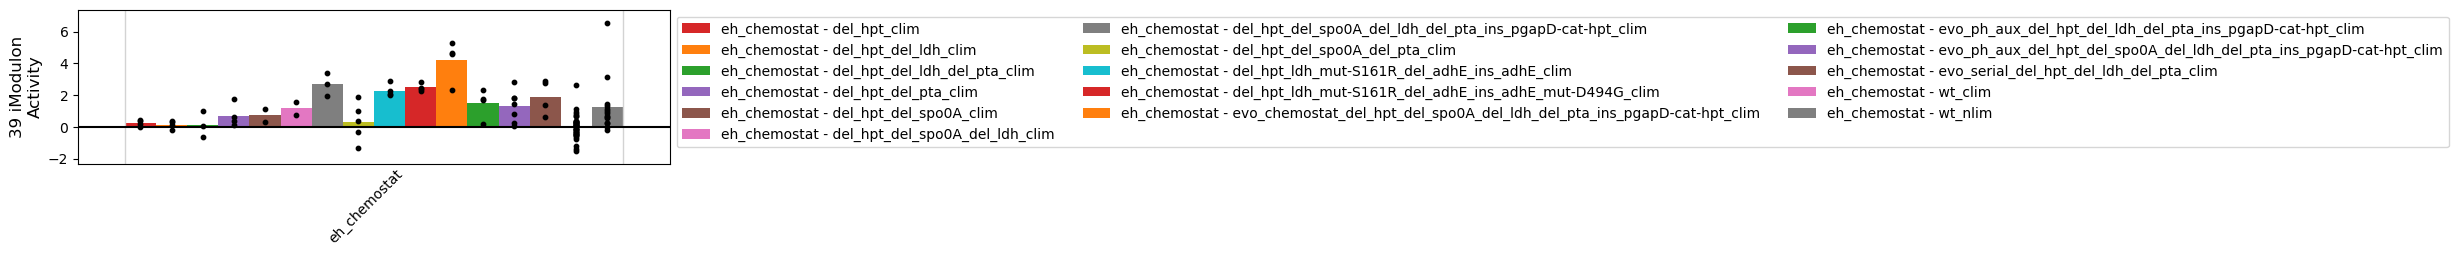

In [285]:
plot_activities(ica_data, imod_of_interest, projects=['eh_chemostat'])

#### merge all renaming dictionaries and then create DF to save

In [ ]:
# first make sure formatting is similar for GRN and orthoICA dictionaries
for k,v in dict_grn_ica.items():
    dict_grn_ica[k] = [v, 'regulatory', '']

# for k,v in dict_ortho_ica_thres_grouped.items():
#     dict_ortho_ica_thres_grouped[k] = [v, 'orthoICA', '']

In [295]:
# then update all at once
dict_rename_imod.update(dict_grn_ica)
dict_rename_imod.update(dict_ortho_ica_thres_grouped)
dict_rename_imod.update(dict_rename_sg_imod)

In [326]:
# then create the mapping
df_rename_imod = pd.DataFrame.from_dict(dict_rename_imod, orient='index', columns = ['IM', 'category', 'source'])

# Generate counts for each occurrence of UC
counts = df_rename_imod.groupby('IM').cumcount()
counts += 1

# # Add the count as a suffix
df_rename_imod['IM'] = df_rename_imod['IM'] + counts.map(lambda x: f'-{x}' if x > 1 else '')
df_rename_imod.loc[df_rename_imod['IM']=='UC', 'IM'] = 'UC-1'

# fill category with uncharacterized
df_rename_imod.loc[df_rename_imod['IM'].str.match(r'^UC-\d+'), 'category'] = 'uncharacterized'

In [328]:
### save
df_rename_imod.to_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t')

# Save final ICA data object as the gene thresholds have changed -- Don't save it for now. Do not change thresholds, if not needed.

In [331]:
save_to_json(ica_data, path.join(data_dir, 'ctherm.json.gz')) #adjusted
ica_data.imodulon_table.to_csv(path.join(data_dir, 'imodulon_table.csv'))

### If need to come back to rename imodulons, do it here

In [2]:
import pandas as pd
from os import path

In [3]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

In [6]:
df_rename_imod = pd.read_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t', index_col=0)

In [9]:
'Sulfate' in df_rename_imod.IM.to_list()

False

In [10]:
dict_rename = {'SO4-tp': 'Sulfate'

}

In [12]:
# rename here
for k,v in dict_rename.items():
    df_rename_imod.loc[df_rename_imod.IM==k, 'IM'] = v

In [15]:
# checking
for k,v in dict_rename.items():
    print(k, df_rename_imod.loc[df_rename_imod.IM==k])
    print(v, df_rename_imod.loc[df_rename_imod.IM==v])


SO4-tp Empty DataFrame
Columns: [IM, category, source]
Index: []
Sulfate          IM    category source
55  Sulfate  functional   kegg


In [16]:
### save again
df_rename_imod.to_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t')

## FIN

# Add biological functions
This is only relevant for 'biological' and 'regulatory iModulons

In [ ]:
subti_annot = pd.read_csv(path.join('..','data','external','subtiwiki_categories.csv'))
subti_annot.rename({'BSU_number':'gene_id'},axis=1,inplace=True)
subti_annot = subti_annot[subti_annot.gene_id.isin(ica_data.gene_names)]

In [ ]:
subti_enrich = ica_data.compute_annotation_enrichment(subti_annot,'FuncName2')
functions = subti_enrich.sort_values('qvalue').drop_duplicates('imodulon').set_index('imodulon')['FuncName2']
functions = functions[ica_data.imodulon_table.category.isin(['regulatory','functional'])]
functions.head()

In [ ]:
ica_data.imodulon_table['function'] = functions

## Manually curate functions

In [174]:
ica_data.imodulon_table.function.value_counts()

AttributeError: 'DataFrame' object has no attribute 'function'

In [ ]:
rename = {'carbon metabolism':'Carbon Metabolism',
          'coping with stress':'Stress Response',
          'amino acid/ nitrogen metabolism':'AA/Nucleotide Metabolism',
          'prophages':'Prophages',
          'sporulation':'Lifestyles',
          'exponential and early post-exponential lifestyles':'Lifestyles',
          'electron transport and ATP synthesis': 'Misc. Metabolism',
          'homeostasis':'Homeostasis',
          'nucleotide metabolism':'AA/Nucleotide Metabolism',
          'proteins of unknown function':'Other',
          'additional metabolic pathways':'Misc. Metabolism',
          'short peptides':'Cellular Processes',
          'essential genes':'Cellular Processes',
          'transporters':'Misc. Metabolism',
          'mobile genetic elements': 'Cellular Processes',
          'ncRNA':'Cellular Processes',
          'mobile genetic elements/ based on similarity':'Cellular Processes',
          'lipid metabolism':'Misc. Metabolism',
          'cell envelope and cell division': 'Cellular Processes',
          'genetics':'Cellular Processes'}

In [ ]:
ica_data.imodulon_table.function = ica_data.imodulon_table.function.replace(rename)

In [ ]:
ica_data.imodulon_table.loc['ybc-operon','function'] = 'Prophages'
ica_data.imodulon_table.loc['SigI','function'] = 'Stress Response'
ica_data.imodulon_table.loc['LnrK','function'] = 'Cellular Processes'
ica_data.imodulon_table.loc['early-biofilm','function'] = 'Lifestyles'
ica_data.imodulon_table.loc['KipR','function'] = 'Misc. Metabolism'
ica_data.imodulon_table.loc['AbrB','function'] = 'Lifestyles'
ica_data.imodulon_table.loc['putative-cssRS','function'] = 'Lifestyles'
ica_data.imodulon_table.loc['YvaF','function'] = 'Other'

In [ ]:
ica_data.imodulon_table.function.value_counts()

## Fill in Uncharacterized and Single Gene iModulons

In [ ]:
ica_data.imodulon_table.function = ['Uncharacterized' if row.category == 'uncharacterized' else
                                    'Single Gene' if row.category == 'single_gene' else row.function
                                    for i,row in ica_data.imodulon_table.iterrows()]


# Save final ICA data object

In [ ]:
save_to_json(ica_data, path.join(data_dir, 'bsu.json.gz'))

In [ ]:
ica_data.imodulon_table.to_csv(path.join(data_dir, 'imodulon_table.csv'))